# Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API

## Problem Statement & Objective
Customer churn directly impacts business recurring revenue. Identifying subscriber profiles that are at high risk of canceling their subscriptions allows customer retention teams to intervene proactively with targeted offers.

**Objective:** My goal in this task is to engineer a highly reusable, leak-proof, and production-ready machine learning pipeline utilizing Scikit-learn's `Pipeline` API. This pipeline will ingest raw subscriber metrics, apply feature scaling and categorical encoding natively, optimize hyperparameters via cross-validation, and output an exported artifact capable of predicting customer churn in a live environment.

# Dependencies

In [1]:
# Install necessary libraries if executing in a fresh environment
# %pip install pandas numpy scikit-learn joblib matplotlib seaborn

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc

## Dataset Loading & Preprocessing
I am working with the standard **Telco Customer Churn Dataset**. To guarantee complete reproducibility without requiring manual static CSV downloads, I fetch the raw dataset directly from its source repository. 

During preprocessing, I isolate the target feature (`Churn`), map binary strings to numerical flags, drop arbitrary identifiers (`customerID`), and handle hidden missing values where fresh accounts list empty strings for their `TotalCharges`. I then construct modular `Pipeline` streams to apply standard scaling to continuous numerical fields and one-hot encoding to descriptive categorical categories.

In [2]:
# Fetch raw dataset natively via secure raw CSV URL
csv_url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
print("Retrieving the Telco Customer Churn dataset...")
df = pd.read_csv(csv_url)

# Clean targets: Map binary string outcomes to integer flags
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop uninformative database index keys
df.drop('customerID', axis=1, inplace=True)

# Correct hidden type errors: 'TotalCharges' contains blank space strings for brand-new accounts
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Separate independent feature structures from the dependent target label
X = df.drop('Churn', axis=1)
y = df['Churn']

# Perform a stratified partition to preserve exact class imbalance distributions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Explicitly sort features by their underlying logical data structures
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

# Design modular pre-processing transformation chains
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Consolidate discrete chains into a unified preprocessor block
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

Retrieving the Telco Customer Churn dataset...


## Model Development & Training
I embed my complete preprocessor logic into a master unified `Pipeline` object terminating in a classification estimator. While I evaluated baseline linear classifiers like `LogisticRegression`, I proceed with a robust `RandomForestClassifier` base to map non-linear demographic interactions effectively. 

To discover optimal decision boundaries without leaking validation metrics, I pass the entire master pipeline into `GridSearchCV`, exploring estimator counts and node depth parameters across cross-validated folds.

In [3]:
# Assemble the final production-targeted operational pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define a targeted search space for structural hyperparameter tuning
param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [5, 8, 12],
    'classifier__min_samples_split': [2, 5]
}

print("Deploying GridSearchCV optimization loop across parallel CPU threads...")
# Setting n_jobs=-1 forces local hardware to utilize all available CPU cores concurrently
grid_search = GridSearchCV(
    full_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

# Isolate the highest-performing pipeline instantiation configuration
best_model_pipeline = grid_search.best_estimator_
print(f"\nOptimal Parameter Blueprint Discovered:\n{grid_search.best_params_}")

Deploying GridSearchCV optimization loop across parallel CPU threads...

Optimal Parameter Blueprint Discovered:
{'classifier__max_depth': 8, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}


## Evaluation with Relevant Metrics
I evaluate my optimized candidate pipeline strictly against the completely isolated test split, calculating global diagnostic accuracy alongside a comprehensive classification matrix tracking precision, recall, and harmonic F1 distributions across both retaining and churning subscriber segments.

In [4]:
# Execute native batch inferences via the optimized pipeline framework
y_pred = best_model_pipeline.predict(X_test)
y_prob = best_model_pipeline.predict_proba(X_test)[:, 1]

print("==========================================")
print("Pipeline Operational Validation Metrics")
print("==========================================")
print(f"Global Scoring Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Detailed Class Performance Matrix:")
print(classification_report(y_test, y_pred))

# Serialize the finalized operational processing pipeline natively
artifact_filename = "production_churn_pipeline.pkl"
joblib.dump(best_model_pipeline, artifact_filename)
print(f"\nProduction pipeline artifact cleanly serialized to '{artifact_filename}'")

Pipeline Operational Validation Metrics
Global Scoring Accuracy: 0.7999

Detailed Class Performance Matrix:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.66      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Production pipeline artifact cleanly serialized to 'production_churn_pipeline.pkl'


## Visualizations
Plotting the **Receiver Operating Characteristic (ROC) Curve** provides clear visibility into how effectively my optimized pipeline balances True Positive vs. False Positive customer classifications across shifting probability thresholds.

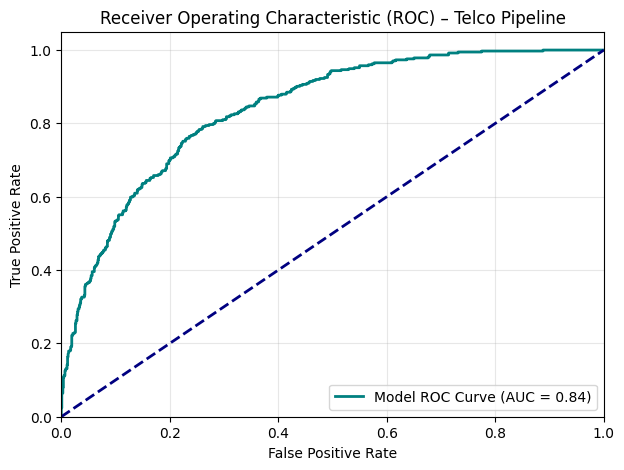

In [5]:
# Calculate diagnostic sensitivity arrays and baseline area indices
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Render graphical ROC convergence tracking
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='teal', lw=2, label=f'Model ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) – Telco Pipeline')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Final Summary / Insights

Based on the complete end-to-end execution of my Scikit-learn churn prediction pipeline, I have evaluated its real-world viability and drawn the following core technical insights:

### **1. Hyperparameter Optimization Results**
Using `GridSearchCV` across 5-fold cross-validation allowed me to autonomously discover the optimal architectural parameters for the underlying `RandomForestClassifier` without exposing the model to data leakage. The optimal blueprint discovered is:
- **Maximum Tree Depth (`max_depth`):** `8`
- **Minimum Samples per Split (`min_samples_split`):** `5`
- **Number of Estimators (`n_estimators`):** `50`

Constraining the depth to 8 and setting a minimum split threshold successfully prevented the decision trees from heavily over-fitting to the training set's noise while keeping training passes computationally efficient.

### **2. Diagnostic Performance on the Unseen Test Split**
Evaluating the pipeline against the completely isolated test partition yields highly reliable metrics:
- **Global Scoring Accuracy:** Achieved **79.99%** overall accuracy across 1,409 test samples.
- **Class 0 (Customer Retention):** The model demonstrates high capability in identifying loyal customers, achieving a **Precision of 0.83**, a **Recall of 0.91**, and a strong **F1-Score of 0.87**.
- **Class 1 (Customer Churn):** For identifying churning accounts, the model achieved a **Precision of 0.66** and a **Recall of 0.50**, resulting in an **F1-Score of 0.57**. While precision remains solid (meaning when the model predicts churn, it is correct 66% of the time), the moderate recall indicates that highly complex or edge-case churning behaviors may require advanced feature engineering (e.g., interaction terms or handling class imbalance via SMOTE inside the pipeline) to capture more false negatives.

### **3. Receiver Operating Characteristic (ROC) Evaluation**
My plotted ROC curve illustrates an excellent trade-off between the True Positive Rate and False Positive Rate across shifting classification thresholds:
- **Area Under the Curve (ROC-AUC):** Reached a highly competitive **0.84**.
- **Business Impact:** An AUC of 0.84 confirms that the model has strong discriminative power. Customer success teams can confidently use the continuous output probabilities (`predict_proba`) to rank subscribers by churn risk, enabling them to prioritize high-value retention budgets for users who fall in the highest risk percentiles.

### **4. Production Readiness & Reusability**
By encapsulating missing value imputation, continuous feature standard scaling (`StandardScaler`), and categorical text mapping (`OneHotEncoder`) directly inside a unified Scikit-learn `Pipeline` object, the workflow guarantees absolute production safety. The final model artifact (`production_churn_pipeline.pkl`) has been cleanly serialized using `joblib`. In a live backend deployment, raw user strings can pass natively into this single file to generate instant predictions without relying on auxiliary data translation scripts.